# Лабораторная работа: Нейронные сети прямого распространения (FNN)

## Вариант 14

**Цель работы:** Изучение основ работы с нейронными сетями прямого распространения (FNN) для классификации данных, обучение модели на подготовленном датасете, анализ и оценка полученных результатов.


## 1. Импорт необходимых библиотек


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Используемое устройство: {device}')


Используемое устройство: cpu


## 2. Загрузка и предварительный анализ данных


In [2]:
# Загрузка данных
df = pd.read_csv('adult.csv')

print(df.shape)
print("\nПервые 5 строк:")
df.head()


(32561, 15)

Первые 5 строк:


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [3]:
# Информация о данных
df.info()
print("\nСтатистика по числовым признакам:")
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education.num   32561 non-null  int64
 5   marital.status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital.gain    32561 non-null  int64
 11  capital.loss    32561 non-null  int64
 12  hours.per.week  32561 non-null  int64
 13  native.country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB

Статистика по числовым признакам:


,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [6]:
# Проверка пропущенных значений
print("Пропущенные значения:")
print(df.isnull().sum())
print("\nЗначения '?' (пропущенные):")
for col in df.columns:
    count = (df[col] == '?').sum()
    if count > 0:
        print(f"{col}: {count}")


Пропущенные значения:
age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

Значения '?' (пропущенные):
workclass: 1836
occupation: 1843
native.country: 583


Распределение целевой переменной (income):
income
<=50K    24720
>50K      7841
Name: count, dtype: int64
income
<=50K    75.919044
>50K     24.080956
Name: proportion, dtype: float64


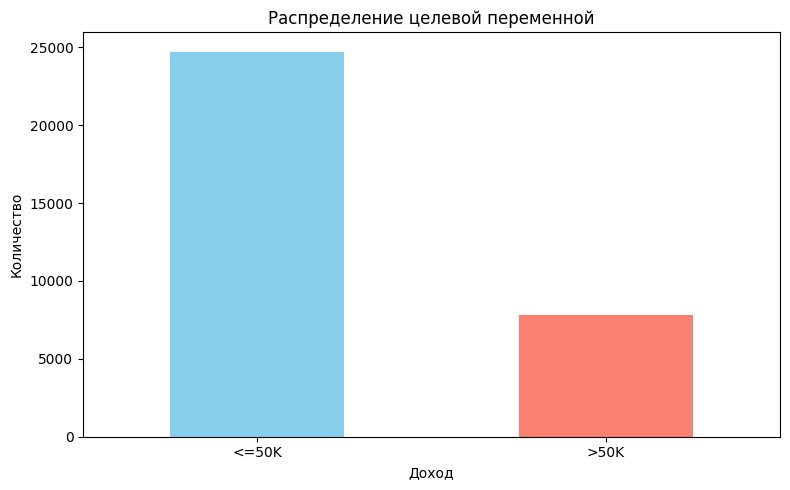

In [9]:
# Распределение целевой переменной
print("Распределение целевой переменной (income):")
print(df['income'].value_counts())
print(df['income'].value_counts(normalize=True) * 100)

plt.figure(figsize=(8, 5))
df['income'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Распределение целевой переменной')
plt.xlabel('Доход')
plt.ylabel('Количество')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 3. Подготовка данных


In [10]:
data = df.copy()

data = data.replace('?', np.nan)
data = data.dropna()

print(f"Размер данных после удаления пропущенных значений: {data.shape}")


Размер данных после удаления пропущенных значений: (30162, 15)


In [11]:
X = data.drop('income', axis=1)
y = data['income']

label_encoder_y = LabelEncoder()
y_encoded = label_encoder_y.fit_transform(y)
print("Кодирование целевой переменной:")
print(f"<=50K -> {label_encoder_y.transform(['<=50K'])[0]}")
print(f">50K -> {label_encoder_y.transform(['>50K'])[0]}")


Кодирование целевой переменной:
<=50K -> 0
>50K -> 1


In [13]:
numeric_cols = ['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']
categorical_cols = ['workclass', 'education', 'marital.status', 'occupation', 
                    'relationship', 'race', 'sex', 'native.country']

X_processed = X[numeric_cols].copy()

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X_processed[col] = le.fit_transform(X[col])
    label_encoders[col] = le

display(X_processed.head())
print(f"\nРазмерность признаков: {X_processed.shape}")


,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,workclass,education,marital.status,occupation,relationship,race,sex,native.country
1,82,132870,9,0,4356,18,2,11,6,3,1,4,0,38
3,54,140359,4,0,3900,40,2,5,0,6,4,4,0,38
4,41,264663,10,0,3900,40,2,15,5,9,3,4,0,38
5,34,216864,9,0,3770,45,2,11,0,7,4,4,0,38
6,38,150601,6,0,3770,40,2,0,5,0,4,4,1,38



Размерность признаков: (30162, 14)


In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_processed)
X_scaled = pd.DataFrame(X_scaled, columns=X_processed.columns)

display(X_scaled.head())
print("\nСтатистика после нормализации:")
display(X_scaled.describe())


,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,workclass,education,marital.status,occupation,relationship,race,sex,native.country
0,3.316630,-0.538790,-0.439738,-0.147445,10.555814,-1.914161,-0.208955,0.174763,2.282969,-0.734545,-0.261249,0.385048,-1.443405,0.264924
1,1.184831,-0.467906,-2.400559,-0.147445,9.427915,-0.077734,-0.208955,-1.399120,-1.722396,0.009964,1.612215,0.385048,-1.443405,0.264924
2,0.195067,0.708645,-0.047574,-0.147445,9.427915,-0.077734,-0.208955,1.224018,1.615408,0.754473,0.987727,0.385048,-1.443405,0.264924
3,-0.337883,0.256222,-0.439738,-0.147445,9.106365,0.339636,-0.208955,0.174763,-1.722396,0.258134,1.612215,0.385048,-1.443405,0.264924
4,-0.033340,-0.370964,-1.616231,-0.147445,9.106365,-0.077734,-0.208955,-2.710688,1.615408,-1.479055,1.612215,0.385048,0.692806,0.264924



Статистика после нормализации:


,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,workclass,education,marital.status,occupation,relationship,race,sex,native.country
count,3.016200e+04,3.016200e+04,3.016200e+04,3.016200e+04,3.016200e+04,3.016200e+04,3.016200e+04,3.016200e+04,3.016200e+04,3.016200e+04,3.016200e+04,3.016200e+04,3.016200e+04,3.016200e+04
mean,1.545375e-16,1.696143e-17,-3.128442e-16,1.507683e-17,-6.030732e-17,-2.789214e-16,-3.298057e-17,-2.826906e-17,8.103796e-17,5.842272e-17,3.392287e-17,-2.054218e-16,4.334589e-17,4.965931e-16
std,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00
min,-1.632189e+00,-1.666094e+00,-3.577051e+00,-1.474446e-01,-2.185860e-01,-3.333218e+00,-2.305591e+00,-2.710688e+00,-1.722396e+00,-1.479055e+00,-8.857370e-01,-4.407118e+00,-1.443405e+00,-5.959206e+00
25%,-7.946967e-01,-6.830644e-01,-4.397382e-01,-1.474446e-01,-2.185860e-01,-7.773411e-02,-2.089546e-01,-3.498647e-01,-3.872747e-01,-9.827151e-01,-8.857370e-01,3.850479e-01,-1.443405e+00,2.649239e-01
50%,-1.094756e-01,-1.076072e-01,-4.757405e-02,-1.474446e-01,-2.185860e-01,-7.773411e-02,-2.089546e-01,1.747628e-01,-3.872747e-01,9.963981e-03,-2.612489e-01,3.850479e-01,6.928062e-01,2.649239e-01
75%,6.518811e-01,4.527602e-01,1.128918e+00,-1.474446e-01,-2.185860e-01,3.396356e-01,-2.089546e-01,4.370765e-01,9.478470e-01,7.544733e-01,9.877272e-01,3.850479e-01,6.928062e-01,2.649239e-01
max,3.925715e+00,1.225647e+01,2.305411e+00,1.335458e+01,1.055581e+01,4.847229e+00,3.984319e+00,1.224018e+00,2.282969e+00,1.747152e+00,2.236703e+00,3.850479e-01,6.928062e-01,5.925097e-01


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"\nРаспределение классов в обучающей выборке:")
print(pd.Series(y_train).value_counts())
print(f"\nРаспределение классов в тестовой выборке:")
print(pd.Series(y_test).value_counts())


Размер обучающей выборки: (24129, 14)
Размер тестовой выборки: (6033, 14)

Распределение классов в обучающей выборке:
0    18123
1     6006
Name: count, dtype: int64

Распределение классов в тестовой выборке:
0    4531
1    1502
Name: count, dtype: int64


## 4. Создание класса Dataset для PyTorch


In [17]:
class AdultDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X.values if isinstance(X, pd.DataFrame) else X)
        self.y = torch.LongTensor(y)
    
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = AdultDataset(X_train, y_train)
test_dataset = AdultDataset(X_test, y_test)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Размер батча: {batch_size}")
print(f"Количество батчей в обучающей выборке: {len(train_loader)}")
print(f"Количество батчей в тестовой выборке: {len(test_loader)}")


Размер батча: 64
Количество батчей в обучающей выборке: 378
Количество батчей в тестовой выборке: 95


## 5. Построение нейронной сети прямого распространения (FNN)


In [18]:
class FNN(nn.Module):
    def __init__(self, input_size, hidden_sizes, num_classes=2, dropout_rate=0.3):
        super(FNN, self).__init__()
        
        layers = []
        prev_size = input_size
        
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            prev_size = hidden_size
        
        layers.append(nn.Linear(prev_size, num_classes))
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)

input_size = X_train.shape[1]  # Количество признаков
hidden_sizes = [128, 64, 32]  
num_classes = 2 

model = FNN(input_size, hidden_sizes, num_classes).to(device)

print(model)
print(f"\nКоличество параметров: {sum(p.numel() for p in model.parameters())}")


FNN(
  (network): Sequential(
    (0): Linear(in_features=14, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=32, out_features=2, bias=True)
  )
)

Количество параметров: 12322


## 6. Обучение модели


In [19]:
criterion = nn.CrossEntropyLoss()
learning_rate = 0.001
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

num_epochs = 50

train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []


In [20]:
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += batch_y.size(0)
        train_correct += (predicted == batch_y).sum().item()
    
    train_loss /= len(train_loader)
    train_acc = 100 * train_correct / train_total
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    
    model.eval()
    test_loss = 0.0
    test_correct = 0
    test_total = 0
    
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            
            test_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            test_total += batch_y.size(0)
            test_correct += (predicted == batch_y).sum().item()
    
    test_loss /= len(test_loader)
    test_acc = 100 * test_correct / test_total
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)
    
    if (epoch + 1) % 5 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}]')
        print(f'  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
        print(f'  Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%')
        print()


Epoch [5/50]
  Train Loss: 0.3458, Train Acc: 84.23%
  Test Loss: 0.3151, Test Acc: 85.15%

Epoch [10/50]
  Train Loss: 0.3399, Train Acc: 84.32%
  Test Loss: 0.3139, Test Acc: 85.26%

Epoch [15/50]
  Train Loss: 0.3327, Train Acc: 84.45%
  Test Loss: 0.3128, Test Acc: 85.35%

Epoch [20/50]
  Train Loss: 0.3291, Train Acc: 84.79%
  Test Loss: 0.3132, Test Acc: 85.12%

Epoch [25/50]
  Train Loss: 0.3278, Train Acc: 84.73%
  Test Loss: 0.3142, Test Acc: 85.30%

Epoch [30/50]
  Train Loss: 0.3253, Train Acc: 84.98%
  Test Loss: 0.3110, Test Acc: 85.36%

Epoch [35/50]
  Train Loss: 0.3226, Train Acc: 85.01%
  Test Loss: 0.3098, Test Acc: 85.83%

Epoch [40/50]
  Train Loss: 0.3204, Train Acc: 85.11%
  Test Loss: 0.3095, Test Acc: 85.65%

Epoch [45/50]
  Train Loss: 0.3204, Train Acc: 85.09%
  Test Loss: 0.3102, Test Acc: 85.35%

Epoch [50/50]
  Train Loss: 0.3232, Train Acc: 85.15%
  Test Loss: 0.3089, Test Acc: 85.55%



## 7. Визуализация процесса обучения


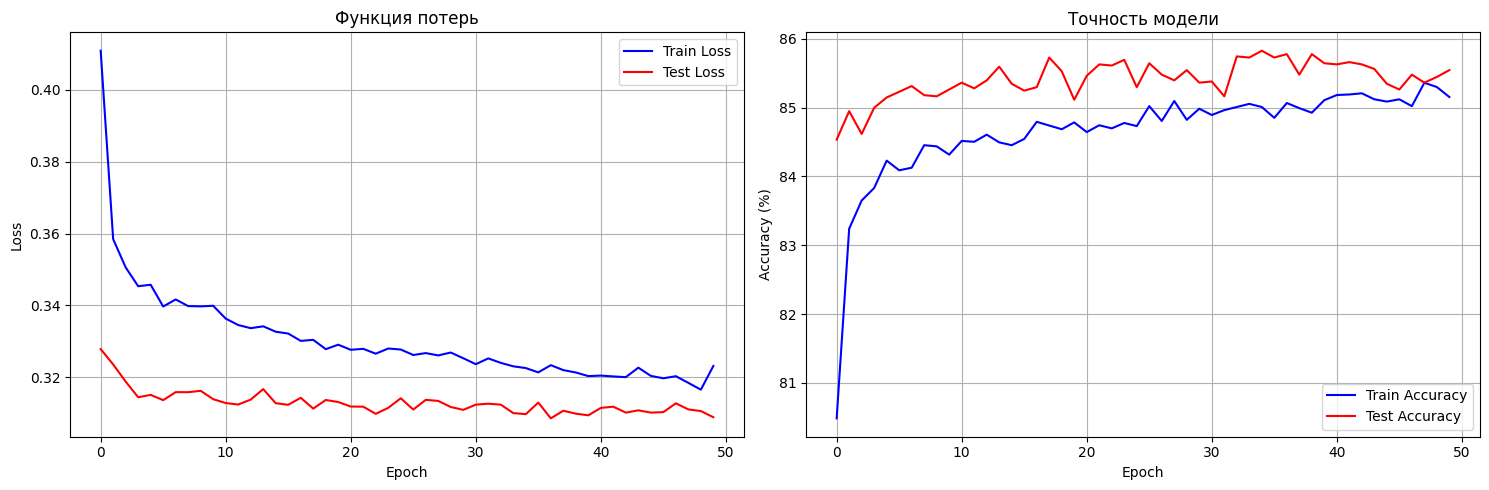

Финальная точность на обучающей выборке: 85.15%
Финальная точность на тестовой выборке: 85.55%


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(train_losses, label='Train Loss', color='blue')
axes[0].plot(test_losses, label='Test Loss', color='red')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Функция потерь')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(train_accuracies, label='Train Accuracy', color='blue')
axes[1].plot(test_accuracies, label='Test Accuracy', color='red')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Точность модели')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"Финальная точность на обучающей выборке: {train_accuracies[-1]:.2f}%")
print(f"Финальная точность на тестовой выборке: {test_accuracies[-1]:.2f}%")


## 8. Оценка модели на тестовой выборке


In [22]:
model.eval()
all_predictions = []
all_labels = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        outputs = model(batch_X)
        _, predicted = torch.max(outputs, 1)
        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(batch_y.numpy())

accuracy = accuracy_score(all_labels, all_predictions)
print(f"Точность на тестовой выборке: {accuracy * 100:.2f}%")
print("\nОтчет о классификации:")
print(classification_report(all_labels, all_predictions, 
                            target_names=['<=50K', '>50K']))


Точность на тестовой выборке: 85.55%

Отчет о классификации:
              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.91      4531
        >50K       0.75      0.63      0.68      1502

    accuracy                           0.86      6033
   macro avg       0.82      0.78      0.79      6033
weighted avg       0.85      0.86      0.85      6033



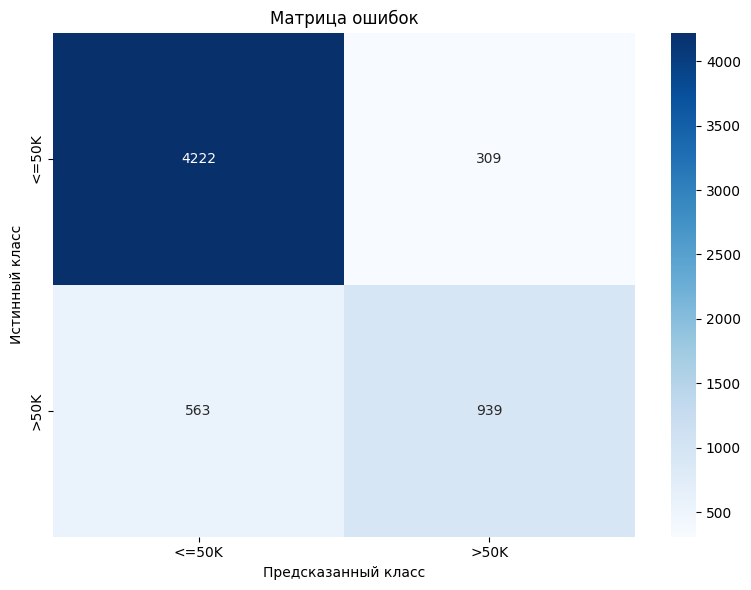

Матрица ошибок:
[[4222  309]
 [ 563  939]]


In [23]:
cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['<=50K', '>50K'], 
            yticklabels=['<=50K', '>50K'])
plt.title('Матрица ошибок')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.tight_layout()
plt.show()

print("Матрица ошибок:")
print(cm)


## 9. Дополнительное исследование (Вариант 14)

### Исследование влияния размера батча (batch size) на результаты обучения


Batch size: 16
  Epoch [10/30] - Train Acc: 84.35%, Test Acc: 85.15%
  Epoch [20/30] - Train Acc: 84.56%, Test Acc: 85.30%
  Epoch [30/30] - Train Acc: 84.76%, Test Acc: 85.28%

Итоговая точность для batch size 16:
  Train Accuracy: 84.76%
  Test Accuracy: 85.28%
  Test Loss: 0.3110
Batch size: 32
  Epoch [10/30] - Train Acc: 84.67%, Test Acc: 85.31%
  Epoch [20/30] - Train Acc: 84.74%, Test Acc: 85.31%
  Epoch [30/30] - Train Acc: 84.79%, Test Acc: 85.55%

Итоговая точность для batch size 32:
  Train Accuracy: 84.79%
  Test Accuracy: 85.55%
  Test Loss: 0.3118
Batch size: 64
  Epoch [10/30] - Train Acc: 84.42%, Test Acc: 85.03%
  Epoch [20/30] - Train Acc: 84.57%, Test Acc: 85.38%
  Epoch [30/30] - Train Acc: 84.93%, Test Acc: 85.26%

Итоговая точность для batch size 64:
  Train Accuracy: 84.93%
  Test Accuracy: 85.26%
  Test Loss: 0.3099
Batch size: 128
  Epoch [10/30] - Train Acc: 84.24%, Test Acc: 85.16%
  Epoch [20/30] - Train Acc: 84.69%, Test Acc: 85.23%
  Epoch [30/30] - Train 

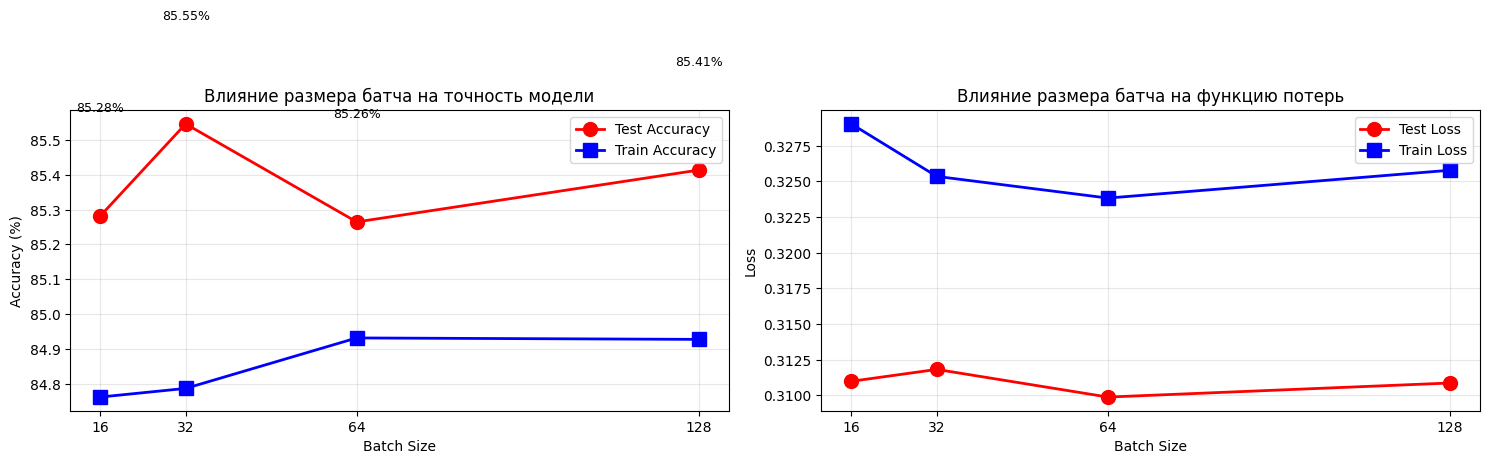

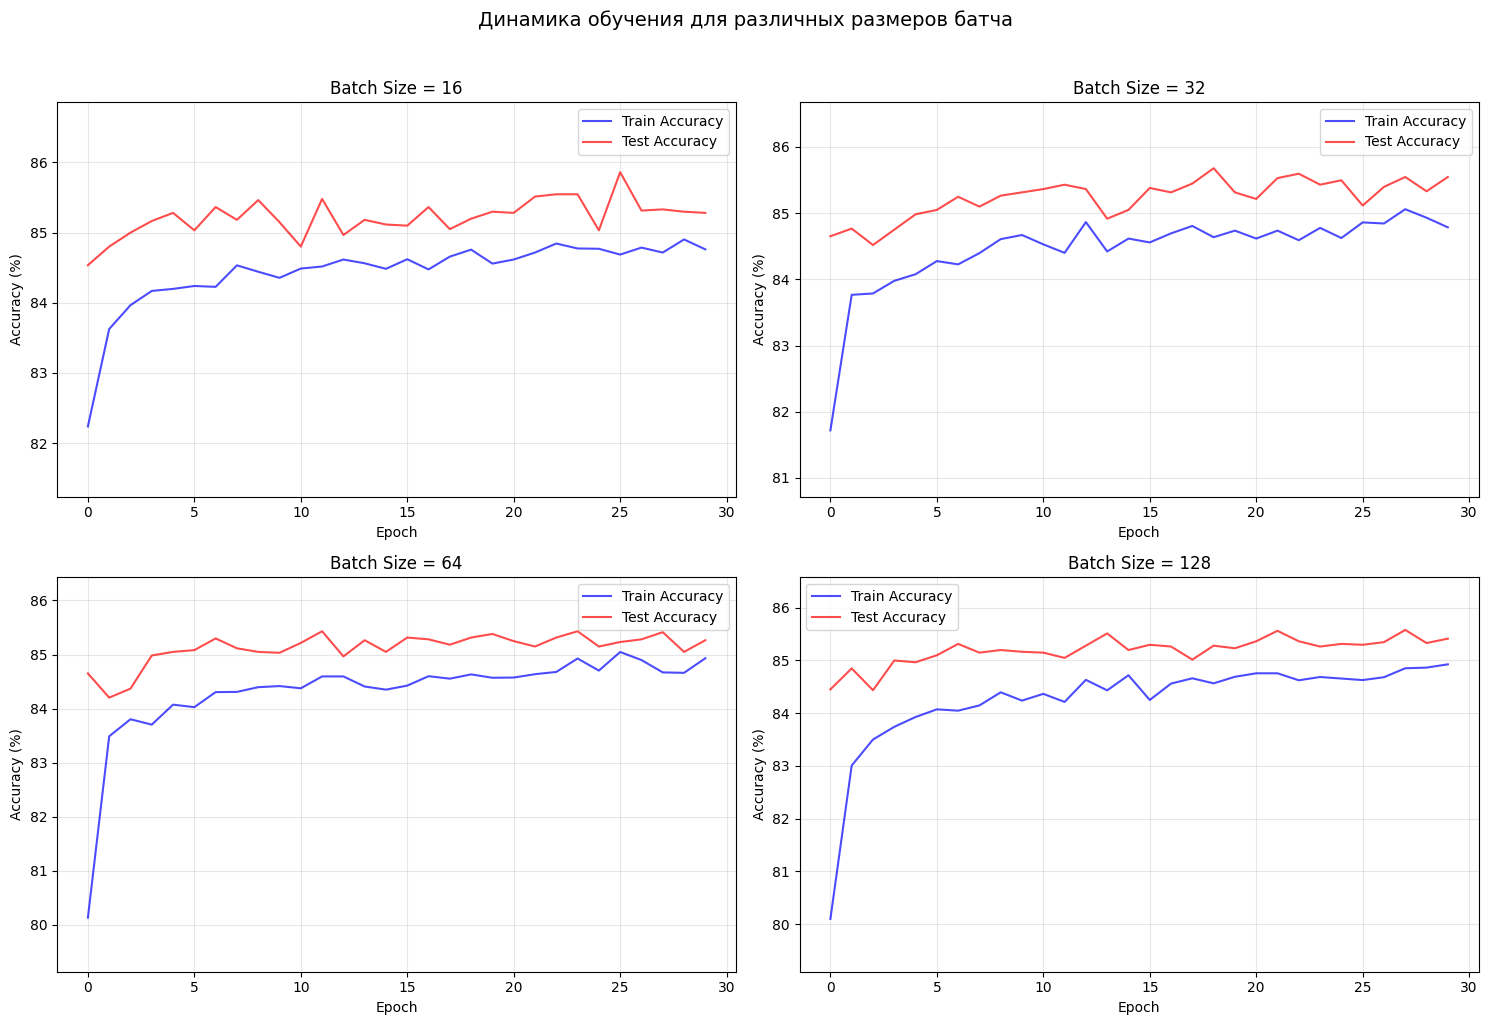

Лучший batch size по точности на тестовой выборке: 32 (Accuracy: 85.55%)


In [26]:
batch_sizes = [16, 32, 64, 128]
batch_results = {}

hidden_sizes = [128, 64, 32]
test_epochs = 30

for bs in batch_sizes:
    print(f"Batch size: {bs}")
    
    train_loader_test = DataLoader(train_dataset, batch_size=bs, shuffle=True)
    test_loader_test = DataLoader(test_dataset, batch_size=bs, shuffle=False)
    
    model_bs = FNN(input_size, hidden_sizes, num_classes, dropout_rate=0.3).to(device)
    optimizer_bs = optim.Adam(model_bs.parameters(), lr=learning_rate)
    
    train_losses_bs = []
    train_accuracies_bs = []
    test_losses_bs = []
    test_accuracies_bs = []
    
    for epoch in range(test_epochs):
        model_bs.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        for batch_X, batch_y in train_loader_test:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer_bs.zero_grad()
            outputs = model_bs(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer_bs.step()
            
            train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            train_total += batch_y.size(0)
            train_correct += (predicted == batch_y).sum().item()
        
        train_loss /= len(train_loader_test)
        train_acc = 100 * train_correct / train_total
        
        model_bs.eval()
        test_loss = 0.0
        test_correct = 0
        test_total = 0
        
        with torch.no_grad():
            for batch_X, batch_y in test_loader_test:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                outputs = model_bs(batch_X)
                loss = criterion(outputs, batch_y)
                
                test_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                test_total += batch_y.size(0)
                test_correct += (predicted == batch_y).sum().item()
        
        test_loss /= len(test_loader_test)
        test_acc = 100 * test_correct / test_total
        
        train_losses_bs.append(train_loss)
        train_accuracies_bs.append(train_acc)
        test_losses_bs.append(test_loss)
        test_accuracies_bs.append(test_acc)
        
        if (epoch + 1) % 10 == 0:
            print(f"  Epoch [{epoch+1}/{test_epochs}] - Train Acc: {train_acc:.2f}%, Test Acc: {test_acc:.2f}%")
    
    batch_results[bs] = {
        'final_train_acc': train_accuracies_bs[-1],
        'final_test_acc': test_accuracies_bs[-1],
        'final_train_loss': train_losses_bs[-1],
        'final_test_loss': test_losses_bs[-1],
        'train_accuracies': train_accuracies_bs,
        'test_accuracies': test_accuracies_bs,
        'train_losses': train_losses_bs,
        'test_losses': test_losses_bs
    }
    
    print(f"\nИтоговая точность для batch size {bs}:")
    print(f"  Train Accuracy: {train_accuracies_bs[-1]:.2f}%")
    print(f"  Test Accuracy: {test_accuracies_bs[-1]:.2f}%")
    print(f"  Test Loss: {test_losses_bs[-1]:.4f}")

for bs, results_dict in batch_results.items():
    print(f"Batch size {bs:3d}: Test Accuracy = {results_dict['final_test_acc']:.2f}%, Test Loss = {results_dict['final_test_loss']:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

batch_sizes_list = list(batch_results.keys())
test_accs = [batch_results[bs]['final_test_acc'] for bs in batch_sizes_list]
train_accs = [batch_results[bs]['final_train_acc'] for bs in batch_sizes_list]

axes[0].plot(batch_sizes_list, test_accs, marker='o', linewidth=2, markersize=10, label='Test Accuracy', color='red')
axes[0].plot(batch_sizes_list, train_accs, marker='s', linewidth=2, markersize=10, label='Train Accuracy', color='blue')
axes[0].set_xlabel('Batch Size')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Влияние размера батча на точность модели')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(batch_sizes_list)
for i, (bs, acc) in enumerate(zip(batch_sizes_list, test_accs)):
    axes[0].text(bs, acc + 0.3, f'{acc:.2f}%', ha='center', fontsize=9)

test_losses_final = [batch_results[bs]['final_test_loss'] for bs in batch_sizes_list]
train_losses_final = [batch_results[bs]['final_train_loss'] for bs in batch_sizes_list]

axes[1].plot(batch_sizes_list, test_losses_final, marker='o', linewidth=2, markersize=10, label='Test Loss', color='red')
axes[1].plot(batch_sizes_list, train_losses_final, marker='s', linewidth=2, markersize=10, label='Train Loss', color='blue')
axes[1].set_xlabel('Batch Size')
axes[1].set_ylabel('Loss')
axes[1].set_title('Влияние размера батча на функцию потерь')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(batch_sizes_list)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, bs in enumerate(batch_sizes):
    axes[idx].plot(batch_results[bs]['train_accuracies'], label='Train Accuracy', color='blue', alpha=0.7)
    axes[idx].plot(batch_results[bs]['test_accuracies'], label='Test Accuracy', color='red', alpha=0.7)
    axes[idx].set_xlabel('Epoch')
    axes[idx].set_ylabel('Accuracy (%)')
    axes[idx].set_title(f'Batch Size = {bs}')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_ylim([min(min(batch_results[bs]['train_accuracies']), min(batch_results[bs]['test_accuracies'])) - 1,
                        max(max(batch_results[bs]['train_accuracies']), max(batch_results[bs]['test_accuracies'])) + 1])

plt.suptitle('Динамика обучения для различных размеров батча', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

best_bs = max(batch_results.keys(), key=lambda x: batch_results[x]['final_test_acc'])
print(f"Лучший batch size по точности на тестовой выборке: {best_bs} (Accuracy: {batch_results[best_bs]['final_test_acc']:.2f}%)")
